### distributions

-----------------

In this notebook, we apply the suppression effects to a complete n(z) in order to recover the full distribution, with both gaussian processes and with a shifted-stretched model (SSM)

In [1]:
import numpy as np 
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import json
from astropy.io import fits
import time

from pathlib import Path
from scipy.integrate import simpson

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf

# specific implementations for modelling 
import src.statistics.sgp as sgp # around gaussian processes
import src.statistics.spline as spl # around splines

ModuleNotFoundError: No module named 'src'

In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

In [3]:
stem = 'v14'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
outdir = ROOT / f'merged_{stem}'
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})
assert all([p.exists() for p in path_dictionary.values()])

In [4]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
tomobin = 3
tracer = 'Merged'
meas = inference.full_npz_tomo(
    path_dictionary=path_dictionary,
    do_bias_correction=False,
    scale_cuts=[.2, 2],
    tracer=tracer,
    tomo_bin=tomobin,
    rebin=1
)
zbins = inference._get_fine_redshift_bins(
    fr=cf.CorrFileReader(path_dictionary['DESI_NGC']),
    tracer=tracer
)
zvals = (zbins[:-1] + zbins[1:]) / 2

Using merged method for tracer Merged and tomo bin 3.


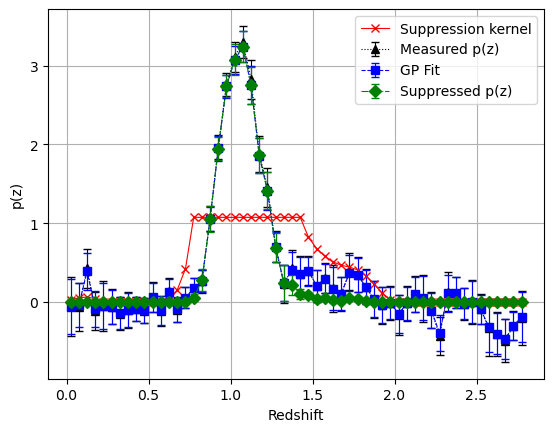

In [5]:
importlib.reload(sgp)
gp = sgp.gpfit(zvals, meas)
suppression_kernel = sgp.suppression(zvals, gp[0], gp[1])
sgp1, sgp2 = sgp.suppress_nz(zvals, gp[0], gp[1], normalize=False)
normalization = np.trapz(sgp1, zvals)

plt.errorbar(zvals, meas[0]/normalization, meas[1]/normalization, capsize=3, color='black', marker='^', linestyle=':', linewidth=0.8, label='Measured p(z)')
plt.errorbar(zvals, gp[0]/normalization, gp[1]/normalization, capsize=3, color='blue', marker='s', linestyle='--', linewidth=0.8, label='GP Fit')
plt.errorbar(zvals, sgp1/normalization, sgp2/normalization, capsize=3, color='green', marker='D', linestyle='-.', linewidth=0.8, label='Suppressed p(z)')
plt.plot(zvals, suppression_kernel/normalization, color='red', marker='x', linestyle='-', linewidth=0.8, label='Suppression kernel')
plt.xlabel('Redshift')
plt.ylabel('p(z)')
plt.legend(loc='upper right')
plt.grid(True)

1. Direct optimization of knot positions...
   Optimized 12 knot positions (Success : True)
\n2. Adaptive refinement...
   Selected 11 knots (χ²/dof = 0.985)


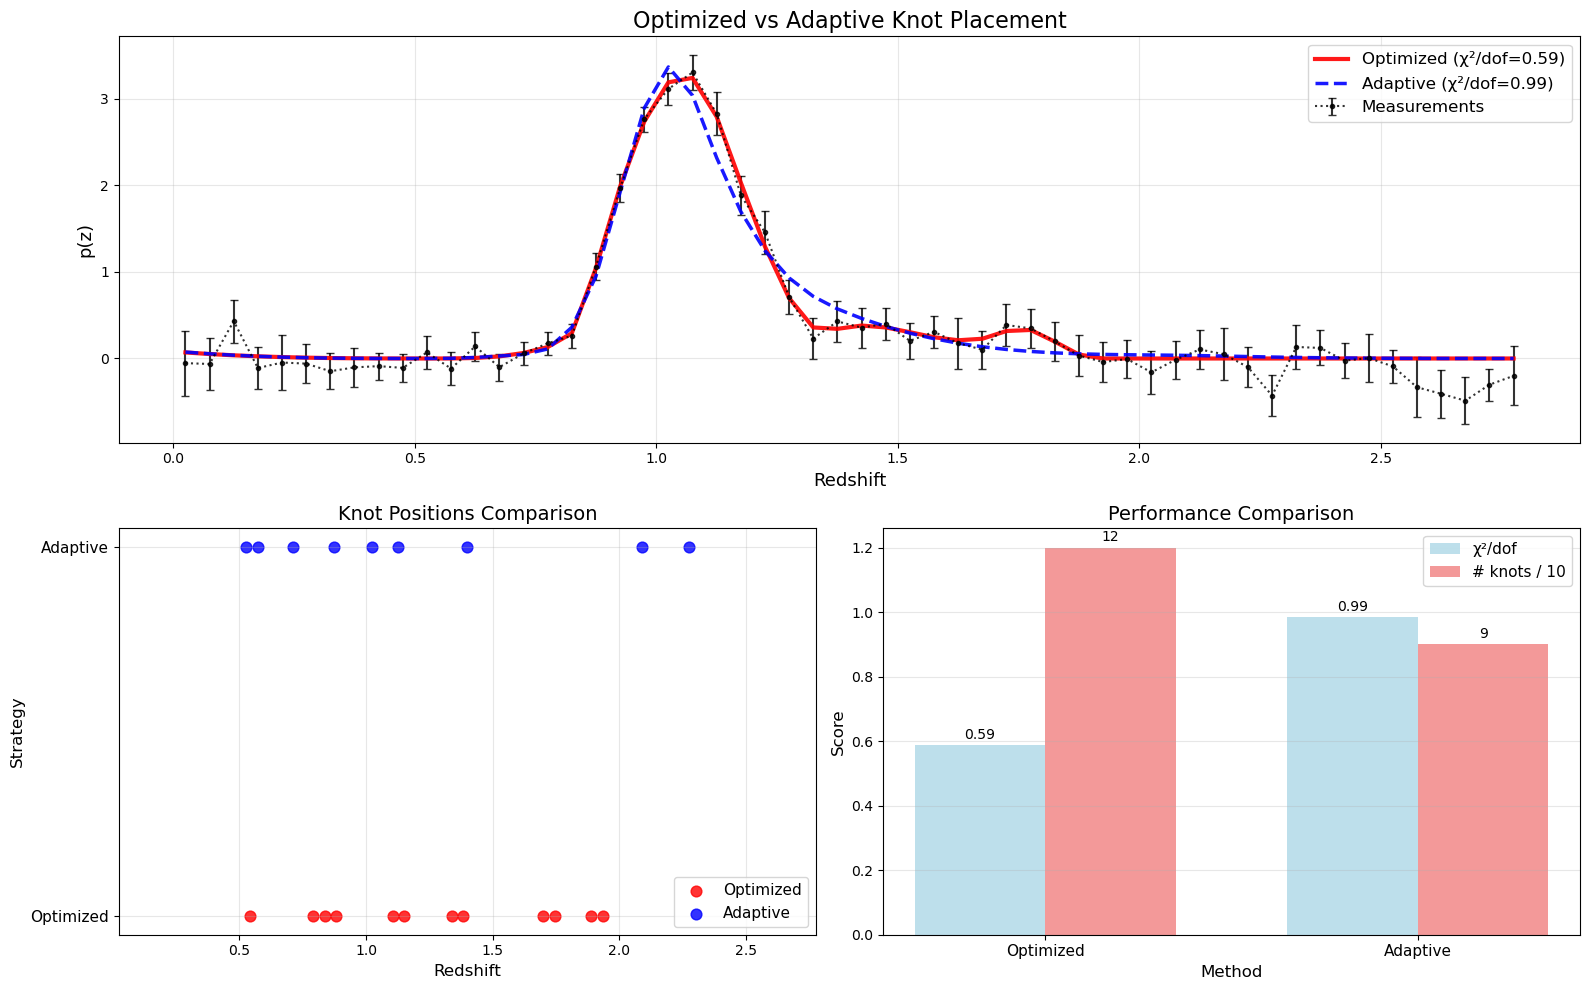

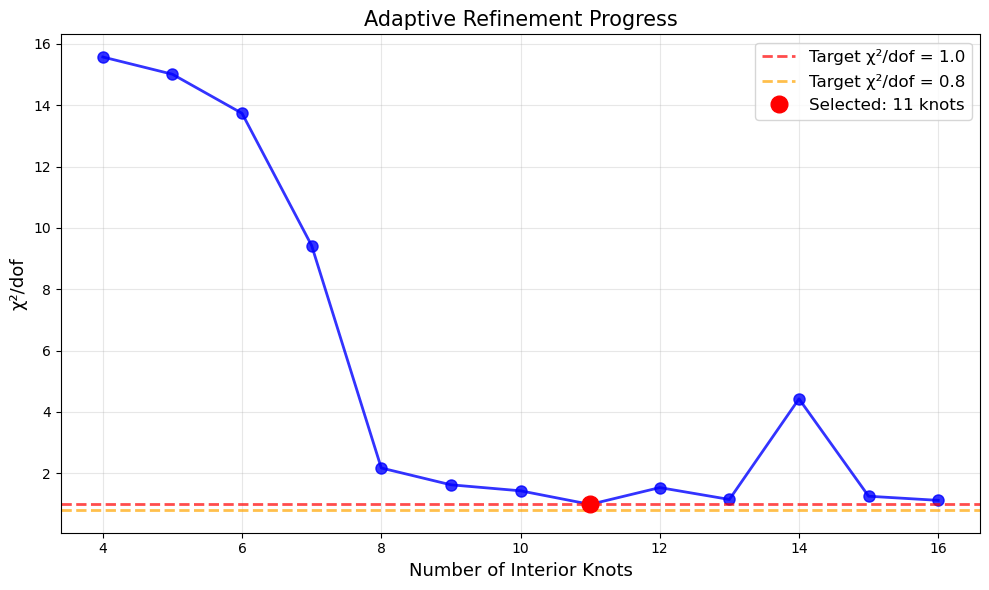

In [6]:
importlib.reload(spl)
knot_strategies = {}

print("1. Direct optimization of knot positions...")
optimal_knots, result = spl.optimize_knot_positions(zvals, meas[0], meas[1], n_knots=12)
knot_strategies['Optimized'] = optimal_knots
print(f"   Optimized {len(optimal_knots)} knot positions (Success : {result.success})")

print("\\n2. Adaptive refinement...")
adaptive_results = spl.adaptive_refinement_knots(zvals, meas[0], meas[1], max_knots=16, target_chi2_red=0.8)
if adaptive_results:
    best_adaptive = min(adaptive_results, key=lambda x: x['chi2_red'])
    knot_strategies['Adaptive'] = best_adaptive['knots']
    print(f"   Selected {best_adaptive['n_knots']} knots (χ²/dof = {best_adaptive['chi2_red']:.3f})")


# Evaluate each strategy
strategy_results = {}
for name, knots in knot_strategies.items():
    try:
        # Fit M-spline with these knots
        x_min, x_max = zvals.min(), zvals.max()
        full_knots = np.concatenate([
            [x_min] * 4, knots, [x_max] * 4
        ])
        
        basis_matrix = spl.mspline_basis(zvals, full_knots, degree=3)
        weights = 1.0 / (meas[1]**2)
        
        A = basis_matrix * np.sqrt(weights)[:, np.newaxis]
        b = meas[0] * np.sqrt(weights)
        
        from scipy.optimize import nnls
        coeffs, _ = nnls(A, b)
        
        # Evaluate on full grid
        basis_full = spl.mspline_basis(zvals, full_knots, degree=3)
        y_pred_full = basis_full @ coeffs
        y_pred_full = np.maximum(y_pred_full, 0)  # Ensure non-negative
        
        # Compute metrics
        residuals = (meas[0] - (basis_matrix @ coeffs)) / meas[1]
        chi2 = np.sum(residuals**2)
        dof = len(meas[0]) - len(coeffs)
        chi2_red = chi2 / dof if dof > 0 else np.inf
        rms = np.sqrt(np.mean(residuals**2))
        
        strategy_results[name] = {
            'knots': knots,
            'chi2_red': chi2_red,
            'rms': rms,
            'prediction': y_pred_full,
            'coeffs': coeffs,
            'n_knots': len(knots)
        }
        
    except Exception as e:
        print(f"\\n{name}: Failed - {e}")

# Create simplified visualization
fig = plt.figure(figsize=(16, 10))

# Main comparison plot
ax1 = plt.subplot(2, 2, (1, 2))
ax1.errorbar(zvals, meas[0]/normalization, meas[1]/normalization, 
             capsize=3, color='black', marker='o', linestyle=':', 
             linewidth=1.5, label='Measurements', alpha=0.8, markersize=3)

colors_strat = ['red', 'blue']
styles_strat = ['-', '--']
widths_strat = [3, 2.5]

for i, (name, result) in enumerate(strategy_results.items()):
    ax1.plot(zvals, result['prediction']/normalization, 
            color=colors_strat[i], linewidth=widths_strat[i], 
            linestyle=styles_strat[i], label=f"{name} (χ²/dof={result['chi2_red']:.2f})", 
            alpha=0.9)

ax1.set_xlabel('Redshift', fontsize=13)
ax1.set_ylabel('p(z)', fontsize=13)
ax1.set_title('Optimized vs Adaptive Knot Placement', fontsize=16)
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(True, alpha=0.3)

# Show knot positions
ax2 = plt.subplot(2, 2, 3)
for i, (name, result) in enumerate(strategy_results.items()):
    knots = result['knots']
    y_pos = i
    ax2.scatter(knots, [y_pos] * len(knots), color=colors_strat[i], 
               s=60, alpha=0.8, label=name)

ax2.set_xlabel('Redshift', fontsize=12)
ax2.set_ylabel('Strategy', fontsize=12)
ax2.set_title('Knot Positions Comparison', fontsize=14)
ax2.set_yticks(range(len(strategy_results)))
ax2.set_yticklabels(list(strategy_results.keys()), fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(zvals.min(), zvals.max())
ax2.legend(fontsize=11)

# Performance comparison
ax3 = plt.subplot(2, 2, 4)
strategy_names = list(strategy_results.keys())
chi2_values = [strategy_results[name]['chi2_red'] for name in strategy_names]
n_knots_values = [strategy_results[name]['n_knots'] for name in strategy_names]

x = np.arange(len(strategy_names))
width = 0.35

# Chi-squared bars
bars1 = ax3.bar(x - width/2, chi2_values, width, label='χ²/dof', 
                color='lightblue', alpha=0.8)

# Number of knots bars (scaled for visibility)
bars2 = ax3.bar(x + width/2, np.array(n_knots_values)/10, width, 
                label='# knots / 10', color='lightcoral', alpha=0.8)

ax3.set_xlabel('Method', fontsize=12)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Performance Comparison', fontsize=14)
ax3.set_xticks(x)
ax3.set_xticklabels(strategy_names, fontsize=11)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars1, chi2_values):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)

for bar, val in zip(bars2, n_knots_values):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Adaptive refinement progression
if adaptive_results:
    fig2, ax = plt.subplots(1, 1, figsize=(10, 6))
    n_knots_list = [r['n_knots'] for r in adaptive_results]
    chi2_list = [r['chi2_red'] for r in adaptive_results]
    
    ax.plot(n_knots_list, chi2_list, 'bo-', linewidth=2, markersize=8, alpha=0.8)
    ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Target χ²/dof = 1.0')
    ax.axhline(y=0.8, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Target χ²/dof = 0.8')
    
    # Highlight the selected solution
    selected_idx = next(i for i, r in enumerate(adaptive_results) if r['n_knots'] == best_adaptive['n_knots'])
    ax.plot(best_adaptive['n_knots'], best_adaptive['chi2_red'], 'ro', markersize=12, 
            label=f'Selected: {best_adaptive["n_knots"]} knots')
    
    ax.set_xlabel('Number of Interior Knots', fontsize=13)
    ax.set_ylabel('χ²/dof', fontsize=13)
    ax.set_title('Adaptive Refinement Progress', fontsize=15)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [7]:
optimal_knots, result = spl.optimize_knot_positions(zvals, meas[0], meas[1], n_knots=12)

In [8]:
def monte_carlo_fit_comparison(z_data, y_data, err_data, knots, n_monte_carlo=300, method='fast'):
    """
    Apply Monte Carlo resampling assuming Gaussian errors to get uncertainty estimates
    
    Parameters:
    -----------
    z_data, y_data, err_data : arrays
        Your redshift and measurement data with uncertainties
    knots : array
        Interior knots for the M-spline basis
    n_monte_carlo : int
        Number of Monte Carlo samples (100-500 typical)
    method : str
        'fast' uses fixed knots, 'full' optimizes knots (much slower)
    
    Returns:
    --------
    results : dict
        Monte Carlo results for each fitting method
    """
    import time
    import numpy as np
    from scipy.optimize import nnls
    
    start_time = time.time()
    z_eval = np.linspace(z_data.min(), z_data.max(), 100)
    knots_interior = np.array(knots)

    # Storage for predictions and coefficients
    results = {
        'bspline_nnls': []
    }
    coeff_list = []

    for i in range(n_monte_carlo):
        # Monte Carlo sample: draw from Gaussian distributions
        y_mc = np.random.normal(y_data, err_data)
        z_mc = z_data.copy()
        err_mc = err_data.copy()

        # Knot selection
        if method == 'fast':
            knots_use = knots_interior
        else:
            knots_use = spl.optimize_knot_positions(
                z_mc, y_mc, err_mc, 
                n_knots=len(knots_interior) + 2
            )[0]

        x_min, x_max = z_mc.min(), z_mc.max()
        full_knots = np.concatenate([[x_min] * 4, knots_use, [x_max] * 4])

        # Construct basis and weighted system
        basis_mc = spl.mspline_basis(z_mc, full_knots, degree=3)
        weights = 1.0 / (err_mc**2)
        A = basis_mc * np.sqrt(weights)[:, np.newaxis]
        b = y_mc * np.sqrt(weights)

        # Solve with NNLS
        coeffs, _ = nnls(A, b)
        coeff_list.append(coeffs)

        # Evaluate on grid
        basis_eval = spl.mspline_basis(z_eval, full_knots, degree=3)
        pred_nnls = basis_eval @ coeffs
        results['bspline_nnls'].append(pred_nnls)

    total_time = time.time() - start_time
    print(f"\nMonte Carlo complete! Total time: {total_time:.1f}s ({total_time/n_monte_carlo:.2f}s per sample)")

    # Convert to arrays and compute statistics
    processed_results = {}
    for method_name, predictions in results.items():
        preds_valid = np.array(predictions)
        n_valid = np.sum(np.isnan(preds_valid))
        if n_valid > 0:
            raise ValueError(f"Some {method_name} fits failed!")

        # Coefficient stats
        coeff_array = np.array(coeff_list)  # shape (n_mc, n_basis)
        coeff_mean = np.mean(coeff_array, axis=0)
        coeff_cov = np.cov(coeff_array, rowvar=False)  # shape (n_basis, n_basis)

        # Propagate covariance to prediction space
        basis_eval = spl.mspline_basis(z_eval, full_knots, degree=3)
        f_var = np.einsum('ij,jk,ik->i', basis_eval, coeff_cov, basis_eval)
        f_std_cov = np.sqrt(f_var)

        processed_results[method_name] = {
            'predictions': preds_valid,
            'mean': np.mean(preds_valid, axis=0),
            'std': np.std(preds_valid, axis=0),
            'lower_68': np.percentile(preds_valid, 16, axis=0),
            'upper_68': np.percentile(preds_valid, 84, axis=0),
            'lower_95': np.percentile(preds_valid, 2.5, axis=0),
            'upper_95': np.percentile(preds_valid, 97.5, axis=0),
            'coefficients': coeff_array,
            'coeff_mean': coeff_mean,
            'coeff_cov': coeff_cov,
            'cov_std': f_std_cov,
        }

    processed_results['z_eval'] = z_eval
    return processed_results


Monte Carlo complete! Total time: 1.0s (0.00s per sample)


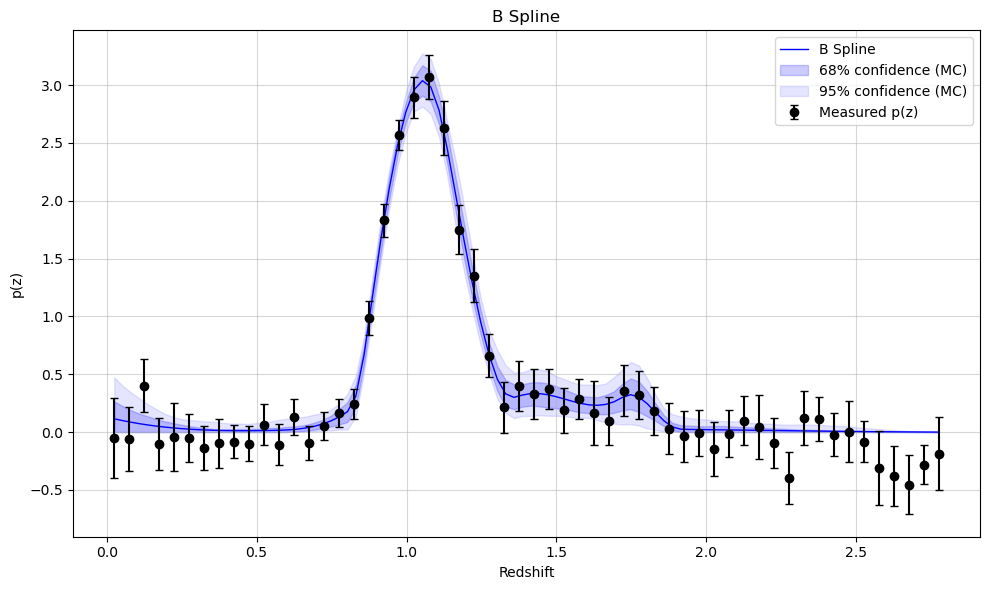

In [11]:
monte_carlo_results = monte_carlo_fit_comparison(
    z_data=zvals, 
    y_data=meas[0], 
    err_data=meas[1], 
    knots=optimal_knots, 
    n_monte_carlo=300, 
    method='fast'
)
color='blue'
fig, ax = plt.subplots(figsize=(10, 6))
result = monte_carlo_results['bspline_nnls']
z_eval = monte_carlo_results['z_eval']

ax.plot(z_eval, result['mean'], color=color, linewidth=1, label=f'B Spline')
ax.errorbar(zvals, meas[0], yerr=meas[1], fmt='o', color='black', label='Measured p(z)', capsize=3)

# Monte Carlo percentile bands
ax.fill_between(z_eval, result['lower_68'], result['upper_68'], 
                color=color, alpha=0.2, label='68% confidence (MC)')
ax.fill_between(z_eval, result['lower_95'], result['upper_95'], 
                color=color, alpha=0.1, label='95% confidence (MC)')

ax.set_xlabel('Redshift')
ax.set_ylabel('p(z)')
ax.set_title(f'B Spline')
ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

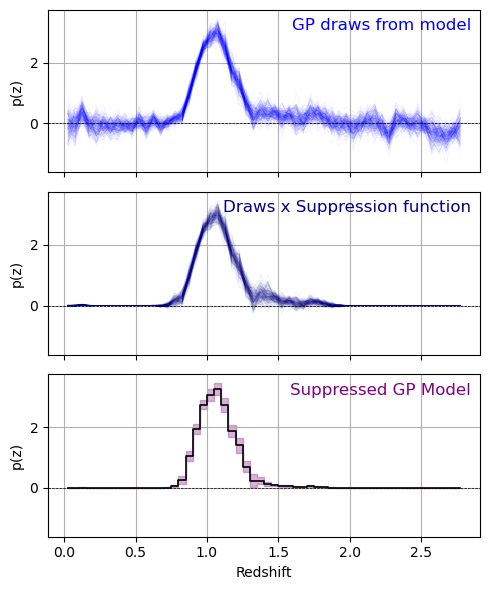

In [8]:
importlib.reload(sgp)

draws = sgp.draw_from_gp(gp[0], gp[1], seed=123, n_draws=200)
suppressed_draws = draws * suppression_kernel[:, np.newaxis]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 1.5*4), sharex=True, sharey=True)

# gp draws
ax1.plot(zvals, draws, color='blue', alpha=0.05, linewidth=0.5)
ax1.grid()
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax1.text(0.98, 0.95, 'GP draws from model', color='blue', fontsize=12, ha='right', va='top', transform=ax1.transAxes)
ax1.set_ylabel('p(z)')

# suppressed draws
ax2.plot(zvals, suppressed_draws, color='darkblue', alpha=0.05, linewidth=0.5)
ax2.grid()
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax2.text(0.98, 0.95, 'Draws x Suppression function', color='darkblue', fontsize=12, ha='right', va='top', transform=ax2.transAxes)
ax2.set_ylabel('p(z)')

# 1σ envelope + median + renormalized suppressed draws
mean, err = sgp.suppress_nz(zvals, gp[0], gp[1])
ax3.fill_between(zvals, mean-err, mean+err, color='purple', alpha=0.3, step='mid')
ax3.plot(zvals, mean, color='black', linewidth=1.2, drawstyle='steps-mid')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax3.grid()
ax3.text(0.98, 0.95, 'Suppressed GP Model', color='purple', fontsize=12, ha='right', va='top', transform=ax3.transAxes)
ax3.set_ylabel('p(z)')

plt.xlabel('Redshift')
plt.tight_layout()
plt.show()


In [12]:
w = comb.trapz_weights(zvals)
mask = (zvals > 1) & (zvals < 2)
mean_nz = np.trapz(mean[mask] * zvals[mask], x=zvals[mask])
mean_nz_err = np.sqrt(np.sum(err**2 * w**2))
print(f'Mean p(z) = {mean_nz:.3f} ± {mean_nz_err:.3f}')

NameError: name 'mean' is not defined

Using merged method for tracer Merged and tomo bin 1.
0 negative values in mean
Area under nz_1 : 0.791
First moment : 0.450
Using merged method for tracer Merged and tomo bin 2.
0 negative values in mean
Area under nz_2 : 0.714
First moment : 0.767
Using merged method for tracer Merged and tomo bin 3.
0 negative values in mean
Area under nz_3 : 0.791
First moment : 1.082
Using merged method for tracer Merged and tomo bin 4.
0 negative values in mean
Area under nz_4 : 0.938
First moment : 1.375
FITS file saved to: nz.fits


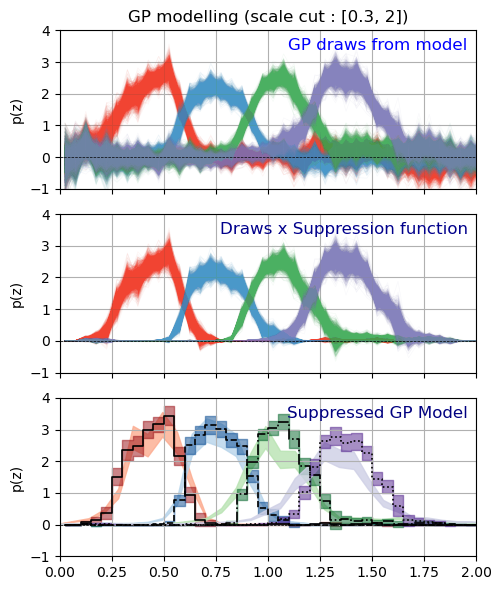

In [ ]:
importlib.reload(sgp)
tracer = 'Merged'
zbins = inference._get_fine_redshift_bins(
        fr=cf.CorrFileReader(path_dictionary['DESI_NGC']),
        tracer=tracer
    )
zvals = (zbins[:-1] + zbins[1:]) / 2
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 6), sharex=True, sharey=True)
scale_cut = [.3, 2]

tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')
mids = tomo_bin_dnnz[:, 0]

# Prepare FITS table data
# Calculate bin edges from midpoints
dz = np.mean(np.diff(zvals))
z_low = zvals - dz/2
z_high = zvals + dz/2
z_mid = zvals

fits_data = {
    'Z_LOW': z_low,
    'Z_MID': z_mid,
    'Z_HIGH': z_high
}

for tb in [1,2,3,4]:
    meas = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        do_bias_correction=False,
        scale_cuts=scale_cut,
        tracer=tracer,
        tomo_bin=tb,
        rebin=1
    )

    gp = sgp.gpfit(zvals, meas)
    suppression_kernel = sgp.suppression(zvals, gp[0], gp[1], damping=0.6)

    draws = sgp.draw_from_gp(gp[0], gp[1], seed=123, n_draws=2000)
    suppressed_draws = draws * suppression_kernel[:, np.newaxis]

    # gp draws
    ax1.plot(zvals, draws, color=colormaps[tb-1](0.6), alpha=0.05, linewidth=0.5)

    # suppressed draws
    ax2.plot(zvals, suppressed_draws, color=colormaps[tb-1](0.6), alpha=0.05, linewidth=0.5)

    # 1σ envelope + mean
    mean, lower, upper = sgp.get_enveloppe(suppressed_draws, sigma_level=1)
    # ensure non-negative values
    mean = np.maximum(mean, 0)
    print(np.sum(mean < 0), 'negative values in mean')
     
    # renormalize to 1
    area = np.trapz(mean, zvals)
    mean /= area
    lower /= area
    upper /= area
    print(f'Area under nz_{tb} : {area:.3f}')
    print(f'First moment : {np.trapz(mean * zvals, zvals):.3f}')

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tb], mids)

    ax3.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colormaps[tb-1](0.3), 
        alpha=0.8
        )

    ax3.fill_between(zvals, lower, upper, color=colormaps[tb-1](0.9), alpha=0.5, step='mid')
    ax3.plot(zvals, mean, color='black', linewidth=1.2, drawstyle='steps-mid', linestyle=linestyles[tb-1])

    # Store data for FITS file
    fits_data[f'BIN_{tb}'] = mean
    #assert np.all(mean >= 0), f'Non-finite values in BIN_{tb}'
    fits_data[f'BIN_{tb}_ERR'] = (upper - lower) / 2

ax1.set_title(f'GP modelling (scale cut : {scale_cut})')
ax1.grid()
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax1.text(0.98, 0.95, 'GP draws from model', color='blue', fontsize=12, ha='right', va='top', transform=ax1.transAxes)
ax1.set_ylabel('p(z)')
ax1.set_xlim(0, 2)
ax2.set_ylim(-1, 4)

ax2.grid()
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax2.text(0.98, 0.95, 'Draws x Suppression function', color='darkblue', fontsize=12, ha='right', va='top', transform=ax2.transAxes)
ax2.set_ylabel('p(z)')
ax2.set_xlim(0, 2)
ax2.set_ylim(-1, 4)

ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax3.grid()
ax3.text(0.98, 0.95, 'Suppressed GP Model', color='navy', fontsize=12, ha='right', va='top', transform=ax3.transAxes)
ax3.set_ylabel('p(z)')
ax3.set_xlim(0, 2)
ax3.set_ylim(-1, 4)

# Create FITS table with proper column ordering
column_order = ['Z_LOW', 'Z_MID', 'Z_HIGH'] + [f'BIN_{i}' for i in [1,2,3,4]] + [f'BIN_{i}_ERR' for i in [1,2,3,4]]
columns = []

for col_name in column_order:
    columns.append(fits.Column(name=col_name, format='E', array=fits_data[col_name]))

# Create binary table HDU
table_hdu = fits.BinTableHDU.from_columns(columns)

# Add metadata to header
table_hdu.header['TRACER'] = tracer
table_hdu.header['SCALECUT'] = json.dumps(scale_cut)

# Create primary HDU and HDU list
primary_hdu = fits.PrimaryHDU()
primary_hdu.header['TRACER'] = tracer
primary_hdu.header['SCALECUT'] = json.dumps(scale_cut)

hdul = fits.HDUList([primary_hdu, table_hdu])

# Write FITS file
outpath = 'nz.fits'
hdul.writeto(outpath, overwrite=True)
print(f'FITS file saved to: {outpath}')

plt.tight_layout()
plt.show()

In [156]:
from astropy.table import Table
tbl = Table.read('nz.fits')
print(tbl['BIN_1'])
print(tbl['BIN_2'])
print(tbl['BIN_3'])
print(tbl['BIN_4'])

   BIN_1    
------------
         0.0
0.0008874261
 0.041747767
  0.08060909
  0.21222833
   1.2768531
   2.4465928
   2.5831563
    3.097884
   3.2430098
         ...
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
         0.0
Length = 56 rows
    BIN_2    
-------------
          0.0
          0.0
  0.013530406
 -0.005650639
-0.0009001103
          0.0
          0.0
          0.0
          0.0
 0.0050564213
          ...
          0.0
          0.0
          0.0
-0.0018227454
          0.0
          0.0
          0.0
          0.0
          0.0
          0.0
Length = 56 rows
    BIN_3     
--------------
           0.0
           0.0
   0.016945753
 -0.0043567186
  -0.001395638
           0.0
           0.0
           0.0
           0.0
           0.0
           ...
           0.0
           0.0
-0.00013336267
  9.754566e-05
           0.0
           0.0
           0.0
           0.0
           0.0
           0.0
